FULL NETWORK
----------------------------
Number of Nodes: 4039
Number of Edges: 88234

Starting Node: 3199
Starting Node Degree: 22

CONNECTED SAMPLE
----------------------------
Number of Nodes: 150
Number of Edges: 766
Connected: True

NETWORK DIAMETER
----------------------------
2

AVERAGE SHORTEST PATH LENGTH
----------------------------
1.931

AVERAGE CLUSTERING COEFFICIENT
----------------------------
0.649

TOP 10 NODES BY DEGREE CENTRALITY
----------------------------
Node 1684: 1.000
Node 3320: 0.195
Node 2754: 0.174
Node 2719: 0.168
Node 3330: 0.168
Node 3076: 0.161
Node 2742: 0.161
Node 3280: 0.161
Node 2778: 0.161
Node 3198: 0.161


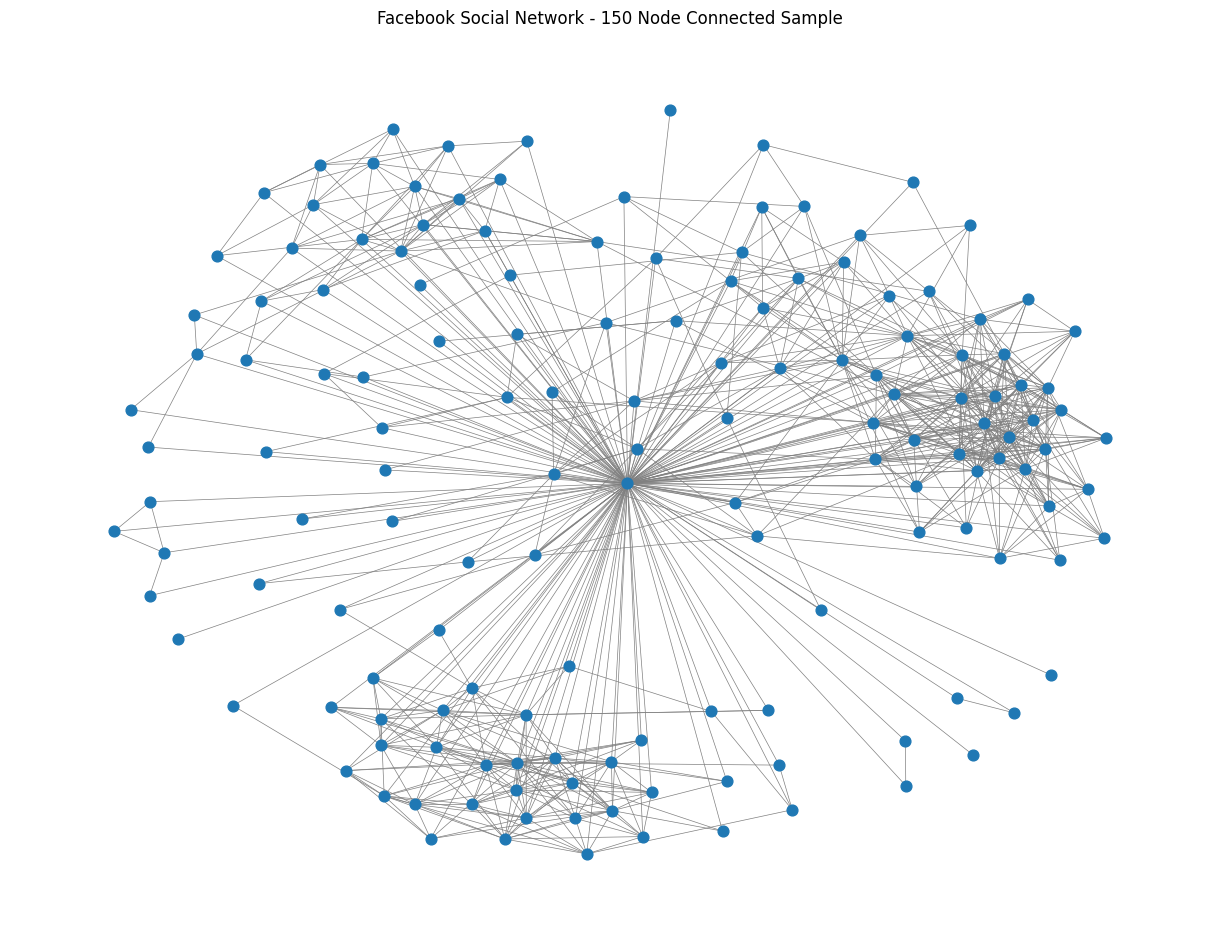


EXPORT COMPLETE
----------------------------
Saved as: facebook_connected_subset.gexf


In [2]:
# ==========================================
# Web Analytics Assignment 2
# Facebook Network Analysis with NetworkX
# ==========================================

import networkx as nx
import matplotlib.pyplot as plt
import random

# -------------------------------------------------
# Load the Facebook dataset
# -------------------------------------------------

G = nx.read_edgelist(
    "/Users/kevindiperna/Desktop/facebook_combined.txt",
    nodetype=int,
    create_using=nx.Graph()
)

print("FULL NETWORK")
print("----------------------------")
print("Number of Nodes:", G.number_of_nodes())
print("Number of Edges:", G.number_of_edges())

# -------------------------------------------------
# Choose a moderately connected starting node
# -------------------------------------------------

# Find nodes with a degree between 20 and 40
candidate_nodes = [
    node for node, degree in G.degree()
    if 20 <= degree <= 40
]

# Use a fixed seed so the results are reproducible
random.seed(42)

start_node = random.choice(candidate_nodes)

print("\nStarting Node:", start_node)
print("Starting Node Degree:", G.degree(start_node))

# -------------------------------------------------
# Create a connected 150-node sample using BFS
# -------------------------------------------------

nodes_subset = list(
    nx.bfs_tree(G, start_node).nodes()
)[:150]

G_sub = G.subgraph(nodes_subset).copy()

print("\nCONNECTED SAMPLE")
print("----------------------------")
print("Number of Nodes:", G_sub.number_of_nodes())
print("Number of Edges:", G_sub.number_of_edges())
print("Connected:", nx.is_connected(G_sub))

# -------------------------------------------------
# Diameter
# -------------------------------------------------

diameter = nx.diameter(G_sub)

print("\nNETWORK DIAMETER")
print("----------------------------")
print(diameter)

# -------------------------------------------------
# Average shortest path length
# -------------------------------------------------

avg_path = nx.average_shortest_path_length(G_sub)

print("\nAVERAGE SHORTEST PATH LENGTH")
print("----------------------------")
print(round(avg_path, 3))

# -------------------------------------------------
# Average clustering coefficient
# -------------------------------------------------

clustering = nx.average_clustering(G_sub)

print("\nAVERAGE CLUSTERING COEFFICIENT")
print("----------------------------")
print(round(clustering, 3))

# -------------------------------------------------
# Degree centrality
# -------------------------------------------------

degree_centrality = nx.degree_centrality(G_sub)

top10 = sorted(
    degree_centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("\nTOP 10 NODES BY DEGREE CENTRALITY")
print("----------------------------")

for node, value in top10:
    print(f"Node {node}: {value:.3f}")

# -------------------------------------------------
# Draw network
# -------------------------------------------------

plt.figure(figsize=(12, 9))

pos = nx.spring_layout(
    G_sub,
    seed=42,
    k=0.35,
    iterations=100
)

nx.draw(
    G_sub,
    pos,
    node_size=60,
    with_labels=False,
    edge_color="gray",
    width=0.5
)

plt.title("Facebook Social Network - 150 Node Connected Sample")
plt.axis("off")
plt.show()

# -------------------------------------------------
# Export for Gephi
# -------------------------------------------------

nx.write_gexf(
    G_sub,
    "facebook_connected_subset.gexf"
)

print("\nEXPORT COMPLETE")
print("----------------------------")
print("Saved as: facebook_connected_subset.gexf")